# Model Set A: Performance Only


# libaries

In [1]:
#cell 1
import pandas as pd
import glob
import os

import numpy as np
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb

from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer
from collections import Counter
import pickle

XGBoostError: 
XGBoost Library (libxgboost.dylib) could not be loaded.
Likely causes:
  * OpenMP runtime is not installed
    - vcomp140.dll or libgomp-1.dll for Windows
    - libomp.dylib for Mac OSX
    - libgomp.so for Linux and other UNIX-like OSes
    Mac OSX users: Run `brew install libomp` to install OpenMP runtime.

  * You are running 32-bit Python on a 64-bit OS

Error message(s): ["dlopen(/Users/madelineshah/Documents/Clones/.venv/lib/python3.13/site-packages/xgboost/lib/libxgboost.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib\n  Referenced from: /Users/madelineshah/Documents/Clones/.venv/lib/python3.13/site-packages/xgboost/lib/libxgboost.dylib\n  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/usr/lib/libomp.dylib' (no such file)"]


# load data

In [ ]:
# cell 2
all_csv_files = (
    glob.glob("../1.Data_Collection_Prep/clean_final_datasets/*.csv"))

In [ ]:
#cell 3
for file in all_csv_files:
    file_name = os.path.splitext(os.path.basename(file))[0]
    globals()[file_name] = pd.read_csv(file)


Loaded 4 CSV files


In [ ]:
#cell 4

all_csv_files

['../1.Data_Collection_Prep/clean_final_datasets\\college_performance_history.csv',
 '../1.Data_Collection_Prep/clean_final_datasets\\nfl_draft_stats.csv',
 '../1.Data_Collection_Prep/clean_final_datasets\\player_master.csv',
 '../1.Data_Collection_Prep/clean_final_datasets\\player_personal_data.csv']

In [ ]:
#cell 5

# call dataframe variables
college_performance = college_performance_history
player_master = player_master

# Data Info

In [ ]:
# Cell 6: check data structure and NA patterns  
print("College Performance Info:")
print(college_performance.info())
print("\nNA counts in college performance:")
na_counts = college_performance.isnull().sum()
print(na_counts[na_counts > 0].sort_values(ascending=False))
print(f"\nUnique athletes in college data: {college_performance['athlete_id'].nunique()}")


College Performance Info:
<class 'pandas.DataFrame'>
RangeIndex: 102046 entries, 0 to 102045
Data columns (total 60 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   year                 102046 non-null  int64  
 1   team                 102046 non-null  str    
 2   conference           102046 non-null  str    
 3   athlete_id           102046 non-null  int64  
 4   player               102046 non-null  str    
 5   position             102046 non-null  str    
 6   passing_completions  7105 non-null    float64
 7   passing_att          7105 non-null    float64
 8   passing_pct          7105 non-null    float64
 9   passing_yds          7105 non-null    float64
 10  passing_td           7105 non-null    float64
 11  passing_int          7105 non-null    float64
 12  passing_ypa          7105 non-null    float64
 13  rushing_car          22110 non-null   float64
 14  rushing_yds          22110 non-null   float64
 15  ru

# prep data

## create target + features

In [ ]:
# Cell 9:
# binary target: 0=Not drafted, 1=Drafted
target_df = player_master[['athlete_id', 'drafted']].copy()

print(f"\nBinary target distribution:")
print(target_df['drafted'].value_counts())
print(f"As percentages:")
print(target_df['drafted'].value_counts(normalize=True))
print(f"\nTarget breakdown:")
print(f"• Not drafted (0): {(target_df['drafted'] == 0).sum():,} players")
print(f"• Drafted (1): {(target_df['drafted'] == 1).sum():,} players")


Binary target distribution:
drafted
0    40577
1     1444
Name: count, dtype: int64
As percentages:
drafted
0    0.965636
1    0.034364
Name: proportion, dtype: float64

Target breakdown:
• Not drafted (0): 40,577 players
• Drafted (1): 1,444 players


In [ ]:
#cell 10
efficiency_columns = [
    'athlete_id',      
    'year',            
    'passing_pct',     
    'passing_ypa',     
    'rushing_ypc',    
    'receiving_ypr',  
    'kicking_pct',    
    'interceptions_avg', 
    'kick_returns_avg',  
    'punt_returns_avg',  
    'punting_ypp'   
]

print("Efficiency metrics for Model A:")
for col in efficiency_columns:
    if col in college_performance.columns:
        if col not in ['athlete_id', 'year']:
            non_null = college_performance[col].notna().sum()
            total = len(college_performance)
            print(f"{col:20}: {non_null:6} non-null ({non_null/total*100:5.1f}%)")

model_a_data = college_performance[efficiency_columns].copy()

print(f"\nModel A raw data shape: {model_a_data.shape}")
print(f"Years covered: {model_a_data['year'].min()} - {model_a_data['year'].max()}")
print(f"Unique athletes: {model_a_data['athlete_id'].nunique()}")

Efficiency metrics for Model A:
passing_pct         :   7105 non-null (  7.0%)
passing_ypa         :   7105 non-null (  7.0%)
rushing_ypc         :  22110 non-null ( 21.7%)
receiving_ypr       :  28027 non-null ( 27.5%)
kicking_pct         :   3248 non-null (  3.2%)
interceptions_avg   :  10206 non-null ( 10.0%)
kick_returns_avg    :   9720 non-null (  9.5%)
punt_returns_avg    :   5209 non-null (  5.1%)
punting_ypp         :   3023 non-null (  3.0%)

Model A raw data shape: (102046, 11)
Years covered: 2014 - 2024
Unique athletes: 42021


In [ ]:
#cell 11: aggregate performance efficiency metrics across all seasons

def aggregate_player_efficiency(df):
    
    numeric_cols = [col for col in df.columns if col not in ['athlete_id', 'year']]
    
    # aggregation functions
    agg_functions = {}
    for col in numeric_cols:
        agg_functions[col] = ['mean', 'max', 'min', 'std', 'count']
    
    # agg by athlete_id
    player_agg = df.groupby('athlete_id').agg(agg_functions)
    
    player_agg.columns = [f"{col[0]}_{col[1]}" for col in player_agg.columns]
    
    player_agg = player_agg.reset_index()
    
    return player_agg

model_a_features = aggregate_player_efficiency(model_a_data)

print(f"Aggregated features shape: {model_a_features.shape}")
print(f"Number of features per player: {model_a_features.shape[1] - 1}")  # -1 for athlete_id
print(f"Sample feature names: {list(model_a_features.columns[1:11])}")  # First 10 feature names

players_with_data = model_a_features['athlete_id'].nunique()
print(f"Players with efficiency data: {players_with_data}")

Aggregated features shape: (42021, 46)
Number of features per player: 45
Sample feature names: ['passing_pct_mean', 'passing_pct_max', 'passing_pct_min', 'passing_pct_std', 'passing_pct_count', 'passing_ypa_mean', 'passing_ypa_max', 'passing_ypa_min', 'passing_ypa_std', 'passing_ypa_count']
Players with efficiency data: 42021


In [ ]:
# Cell 12: Merge efficiency with binary target variable
final_dataset = model_a_features.merge(target_df[['athlete_id', 'drafted']], on='athlete_id', how='inner')
print(f"Final dataset shape: {final_dataset.shape}")
print(f"Players in final dataset: {len(final_dataset)}")

# get features and binary target to X and Y
X = final_dataset.drop(['athlete_id', 'drafted'], axis=1)
y = final_dataset['drafted']

print(f"\nFeature matrix shape: {X.shape}")
print(f"Binary target distribution:")
print(y.value_counts())
print(f"Class breakdown: Not drafted: {(y==0).sum()}, Drafted: {(y==1).sum()}")

Final dataset shape: (42021, 47)
Players in final dataset: 42021

Feature matrix shape: (42021, 45)
Binary target distribution:
drafted
0    40577
1     1444
Name: count, dtype: int64
Class breakdown: Not drafted: 40577, Drafted: 1444


### handle NAs from college history

In [ ]:
# Cell 13: Handle missing values and prepare for modeling

# what percentage of each feature is missing
na_percentages = (X.isnull().sum() / len(X)) * 100
print("Features by percentage of missing values:")
print(na_percentages.sort_values(ascending=False).head(10))

# keep features with <95% missing values
features_to_keep = na_percentages[na_percentages < 95].index.tolist()
print(f"\nKeeping {len(features_to_keep)} features with <95% missing values")

# clean feature matrix
X_clean = X[features_to_keep].copy()
print(f"Clean feature matrix shape: {X_clean.shape}")

# final feature set
print(f"\nFinal Model A features:")
for i, feat in enumerate(X_clean.columns):
    if i % 5 == 0 and i > 0:
        print()  
    print(f"{feat:25}", end=" ")

Features by percentage of missing values:
punting_ypp_std         98.115228
kicking_pct_std         98.072392
punt_returns_avg_std    97.427477
punting_ypp_min         96.461293
punting_ypp_max         96.461293
punting_ypp_mean        96.461293
kicking_pct_min         96.056734
kicking_pct_mean        96.056734
kicking_pct_max         96.056734
passing_pct_std         95.744985
dtype: float64

Keeping 34 features with <95% missing values
Clean feature matrix shape: (42021, 34)

Final Model A features:
passing_pct_mean          passing_pct_max           passing_pct_min           passing_pct_count         passing_ypa_mean          
passing_ypa_max           passing_ypa_min           passing_ypa_count         rushing_ypc_mean          rushing_ypc_max           
rushing_ypc_min           rushing_ypc_std           rushing_ypc_count         receiving_ypr_mean        receiving_ypr_max         
receiving_ypr_min         receiving_ypr_std         receiving_ypr_count       kicking_pct_count    

##  prep data splits

In [ ]:
# Cell 14: Handle missing values and class imbalance
print("Original class distribution:")
print(Counter(y))

# NaN values
print(f"NaN values before imputation: {X_clean.isnull().sum().sum()}")
imputer = SimpleImputer(strategy='constant', fill_value=0)
X_imputed = pd.DataFrame(
    imputer.fit_transform(X_clean),
    columns=X_clean.columns,
    index=X_clean.index
)
print(f"NaN values after imputation: {X_imputed.isnull().sum().sum()}")

# load universal split
with open('test_train_split/athlete_split.pkl', 'rb') as f:
    split = pickle.load(f)

# split based on athlete_id
train_mask = final_dataset['athlete_id'].isin(split['train_athlete_ids'])
test_mask = final_dataset['athlete_id'].isin(split['test_athlete_ids'])

X_train_pre_smote = X_imputed[train_mask]
X_test = X_imputed[test_mask]
y_train_pre_smote = y[train_mask]
y_test = y[test_mask]

# SMOTE only on training data
smote = SMOTE(
    sampling_strategy={
        0: (y_train_pre_smote==0).sum(),  # majority class stays as-is
        1: min((y_train_pre_smote==0).sum() // 3, 15000)  
    },
    random_state=42,
    k_neighbors=5
)

X_train, y_train = smote.fit_resample(X_train_pre_smote, y_train_pre_smote)

print(f"Training: {X_train_pre_smote.shape[0]} → {X_train.shape[0]} (after SMOTE)")
print(f"Test: {X_test.shape[0]} (unchanged)")
print(f"Training class distribution: {Counter(y_train)}")
print(f"Test class distribution: {Counter(y_test)}")

Original class distribution:
Counter({0: 40577, 1: 1444})
NaN values before imputation: 892156
NaN values after imputation: 0
Applying SMOTE to training data only...


Training: 33616 → 43281 (after SMOTE)
Test: 8405 (unchanged)
Training class distribution: Counter({0: 32461, 1: 10820})
Test class distribution: Counter({0: 8116, 1: 289})


# random forest

## train model

In [ ]:
# Cell 15: train Random Forest
model_a_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    max_depth=10,
    min_samples_split=50
)

model_a_rf.fit(X_train, y_train)

# predictions
y_pred = model_a_rf.predict(X_test)
y_pred_proba = model_a_rf.predict_proba(X_test)

print("\nRandom Forest Model A (Draft Prediction) Results:")
print(classification_report(y_test, y_pred, target_names=['Not Drafted', 'Drafted']))

# Binary AUC
auc_score = roc_auc_score(y_test, y_pred_proba[:, 1])
print(f"AUC Score: {auc_score:.4f}")


Training Binary Model A (RF)...

Random Forest Model A (Draft Prediction) Results:
              precision    recall  f1-score   support

 Not Drafted       0.98      0.86      0.91      8116
     Drafted       0.10      0.45      0.16       289

    accuracy                           0.84      8405
   macro avg       0.54      0.65      0.54      8405
weighted avg       0.95      0.84      0.89      8405

AUC Score: 0.7402


## Assess Model

Top 15 Most Important Efficiency Features in Model A:
                    feature  importance
17      receiving_ypr_count    0.146075
23  interceptions_avg_count    0.086594
22    interceptions_avg_std    0.074702
12        rushing_ypc_count    0.067782
20    interceptions_avg_max    0.059888
16        receiving_ypr_std    0.048782
13       receiving_ypr_mean    0.047179
15        receiving_ypr_min    0.045037
14        receiving_ypr_max    0.041951
19   interceptions_avg_mean    0.036372
7         passing_ypa_count    0.030802
11          rushing_ypc_std    0.027385
28   kick_returns_avg_count    0.024959
8          rushing_ypc_mean    0.023827
3         passing_pct_count    0.021597


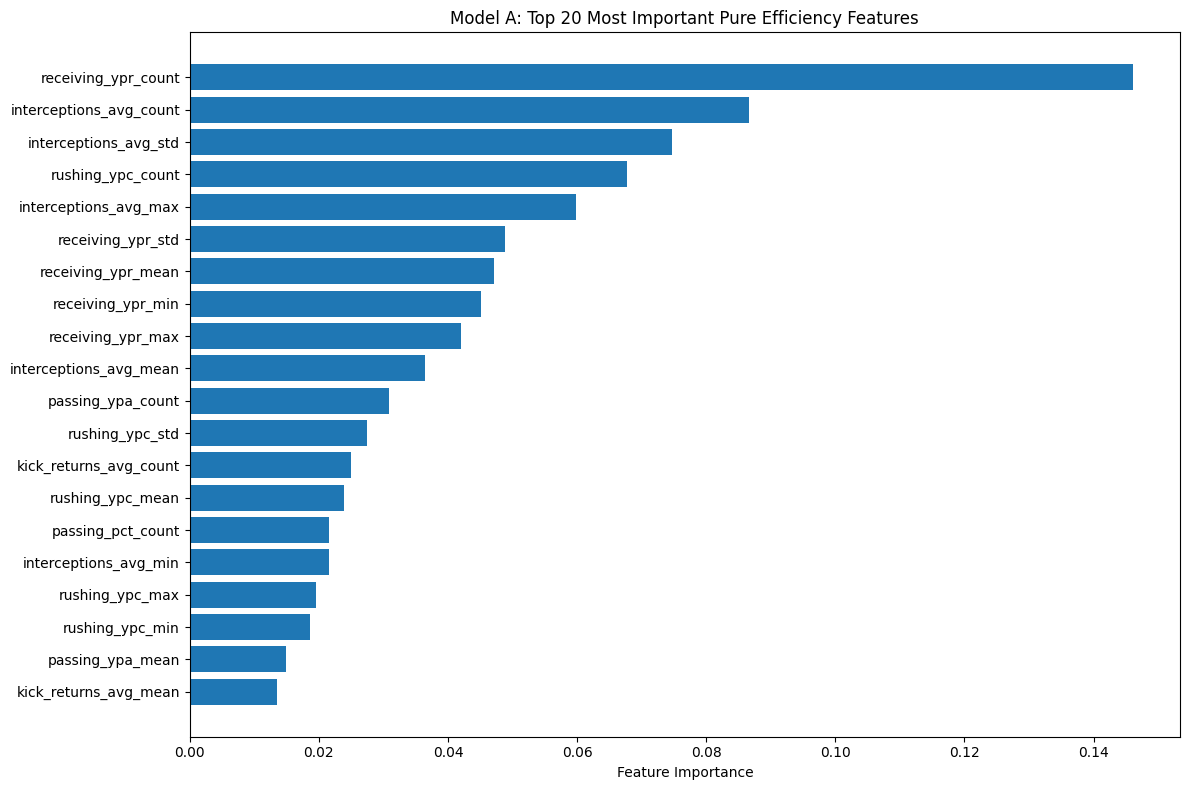


Importance by statistic type:
receiving_ypr       : 0.3290
interceptions_avg   : 0.2791
rushing_ypc         : 0.1573
passing_ypa         : 0.0674
kick_returns        : 0.0672
passing_pct         : 0.0512
punt_returns        : 0.0385
punting_ypp         : 0.0060
kicking_pct         : 0.0042


In [ ]:
# Cell 16: feature importance

feature_importance = pd.DataFrame({
    'feature': X_clean.columns,
    'importance': model_a_rf.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 15 Most Important Efficiency Features in Model A:")
print(feature_importance.head(15))

plt.figure(figsize=(12, 8))
top_features = feature_importance.head(20)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Feature Importance')
plt.title('Model A: Top 20 Most Important Pure Efficiency Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# importance by stat type
print("\nImportance by statistic type:")
stat_types = {}
for _, row in feature_importance.iterrows():
    stat_base = row['feature'].split('_')[0] + '_' + row['feature'].split('_')[1]
    if stat_base not in stat_types:
        stat_types[stat_base] = 0
    stat_types[stat_base] += row['importance']

for stat, importance in sorted(stat_types.items(), key=lambda x: x[1], reverse=True):
    print(f"{stat:20}: {importance:.4f}")

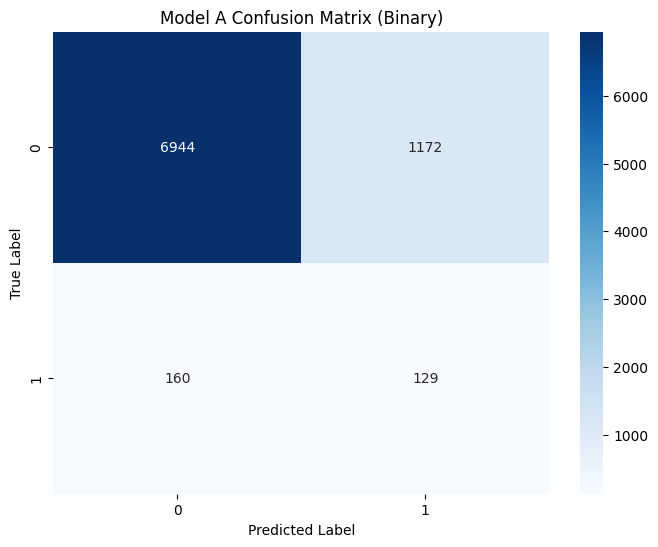

In [ ]:
# Cell 17: confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Model A Confusion Matrix (Binary)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label') 
plt.show()

# XGBoost

In [ ]:
# Cell 18: XGBoost (binary classification)
model_a_xgb = xgb.XGBClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',  
    objective='binary:logistic' 
)

model_a_xgb.fit(X_train, y_train)



Training Binary Model A (XGBoost)...


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [ ]:

# Cell 19: predictions xgboost
y_pred_xgb = model_a_xgb.predict(X_test)
y_pred_proba_xgb = model_a_xgb.predict_proba(X_test)



In [ ]:
print("\nXGBoost Model A (Draft Prediction) Results:")
print(classification_report(y_test, y_pred_xgb, target_names=['Not Drafted', 'Drafted']))

xgb_auc = roc_auc_score(y_test, y_pred_proba_xgb[:, 1])
print(f"AUC Score: {xgb_auc:.4f}")


XGBoost Model A (Draft Prediction) Results:
              precision    recall  f1-score   support

 Not Drafted       0.97      0.99      0.98      8116
     Drafted       0.24      0.12      0.16       289

    accuracy                           0.96      8405
   macro avg       0.61      0.55      0.57      8405
weighted avg       0.94      0.96      0.95      8405

AUC Score: 0.6992


Top 15 Most Important Features - XGBoost Model A:
                    feature  importance
17      receiving_ypr_count    0.129761
7         passing_ypa_count    0.111496
23  interceptions_avg_count    0.074143
22    interceptions_avg_std    0.062550
12        rushing_ypc_count    0.056743
28   kick_returns_avg_count    0.040639
20    interceptions_avg_max    0.039619
32   punt_returns_avg_count    0.036958
3         passing_pct_count    0.033707
4          passing_ypa_mean    0.032529
15        receiving_ypr_min    0.023581
14        receiving_ypr_max    0.023505
1           passing_pct_max    0.022452
18        kicking_pct_count    0.021812
8          rushing_ypc_mean    0.021798


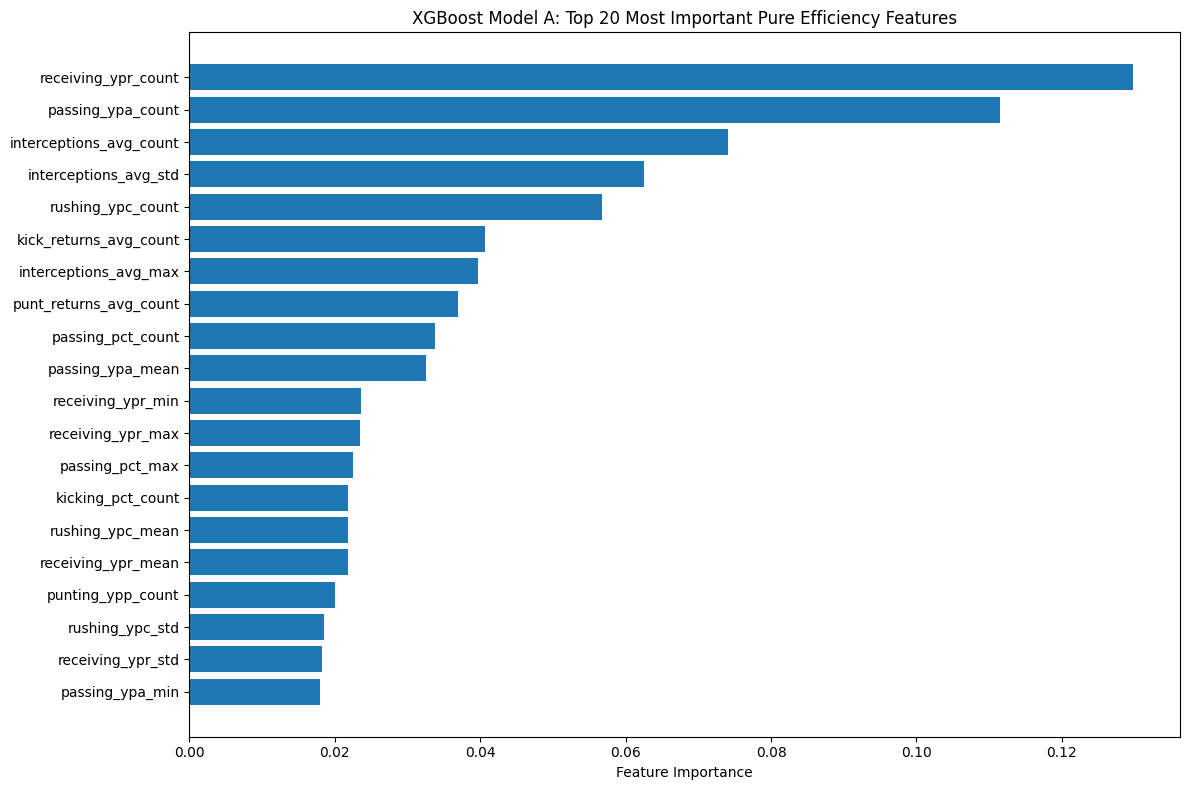


XGBoost Importance by statistic type:
receiving_ypr       : 0.2169
interceptions_avg   : 0.2018
passing_ypa         : 0.1741
rushing_ypc         : 0.1257
passing_pct         : 0.0852
kick_returns        : 0.0849
punt_returns        : 0.0694
kicking_pct         : 0.0218
punting_ypp         : 0.0200


In [ ]:
# Cell 20: XGBoost feature importance
xgb_feature_importance = pd.DataFrame({
    'feature': X_clean.columns,
    'importance': model_a_xgb.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 15 Most Important Features - XGBoost Model A:")
print(xgb_feature_importance.head(15))

plt.figure(figsize=(12, 8))
top_features_xgb = xgb_feature_importance.head(20)
plt.barh(range(len(top_features_xgb)), top_features_xgb['importance'])
plt.yticks(range(len(top_features_xgb)), top_features_xgb['feature'])
plt.xlabel('Feature Importance')
plt.title('XGBoost Model A: Top 20 Most Important Pure Efficiency Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# importance by stat type
print("\nXGBoost Importance by statistic type:")
xgb_stat_types = {}
for _, row in xgb_feature_importance.iterrows():
    stat_base = row['feature'].split('_')[0] + '_' + row['feature'].split('_')[1]
    if stat_base not in xgb_stat_types:
        xgb_stat_types[stat_base] = 0
    xgb_stat_types[stat_base] += row['importance']

for stat, importance in sorted(xgb_stat_types.items(), key=lambda x: x[1], reverse=True):
    print(f"{stat:20}: {importance:.4f}")

# Compare

In [ ]:
# Cell 21: AUC scores 

rf_auc = roc_auc_score(y_test, y_pred_proba[:, 1])
print(f"Random Forest AUC: {rf_auc:.4f}")

xgb_auc = roc_auc_score(y_test, y_pred_proba_xgb[:, 1])
print(f"XGBoost AUC: {xgb_auc:.4f}")

# recall for drafted players
rf_recall_drafted = (y_pred[y_test==1] == 1).mean() if (y_test==1).sum() > 0 else 0
xgb_recall_drafted = (y_pred_xgb[y_test==1] == 1).mean() if (y_test==1).sum() > 0 else 0

print(f"\nRecall for Drafted Players:")
print(f"  Random Forest: {rf_recall_drafted:.1%}")
print(f"  XGBoost:       {xgb_recall_drafted:.1%}")

Calculating AUC scores...
Random Forest AUC: 0.7402
XGBoost AUC: 0.6992

Recall for Drafted Players:
  Random Forest: 44.6%
  XGBoost:       12.1%


In [ ]:
# Cell 22: Performance metrics comparison

print(f"ROC AUC Scores:")
print(f"  Random Forest: {rf_auc:.4f}")
print(f"  XGBoost:       {xgb_auc:.4f}")
print(f"  Difference:    {xgb_auc - rf_auc:+.4f}")

print(f"\nRecall for Drafted Players:")
print(f"  Random Forest: {rf_recall_drafted:.1%}")
print(f"  XGBoost:       {xgb_recall_drafted:.1%}")
print(f"  Difference:    {xgb_recall_drafted - rf_recall_drafted:+.1%}")

MODEL A COMPARISON: RANDOM FOREST vs XGBOOST (BINARY)
ROC AUC Scores:
  Random Forest: 0.7402
  XGBoost:       0.6992
  Difference:    -0.0410

Recall for Drafted Players:
  Random Forest: 44.6%
  XGBoost:       12.1%
  Difference:    -32.5%


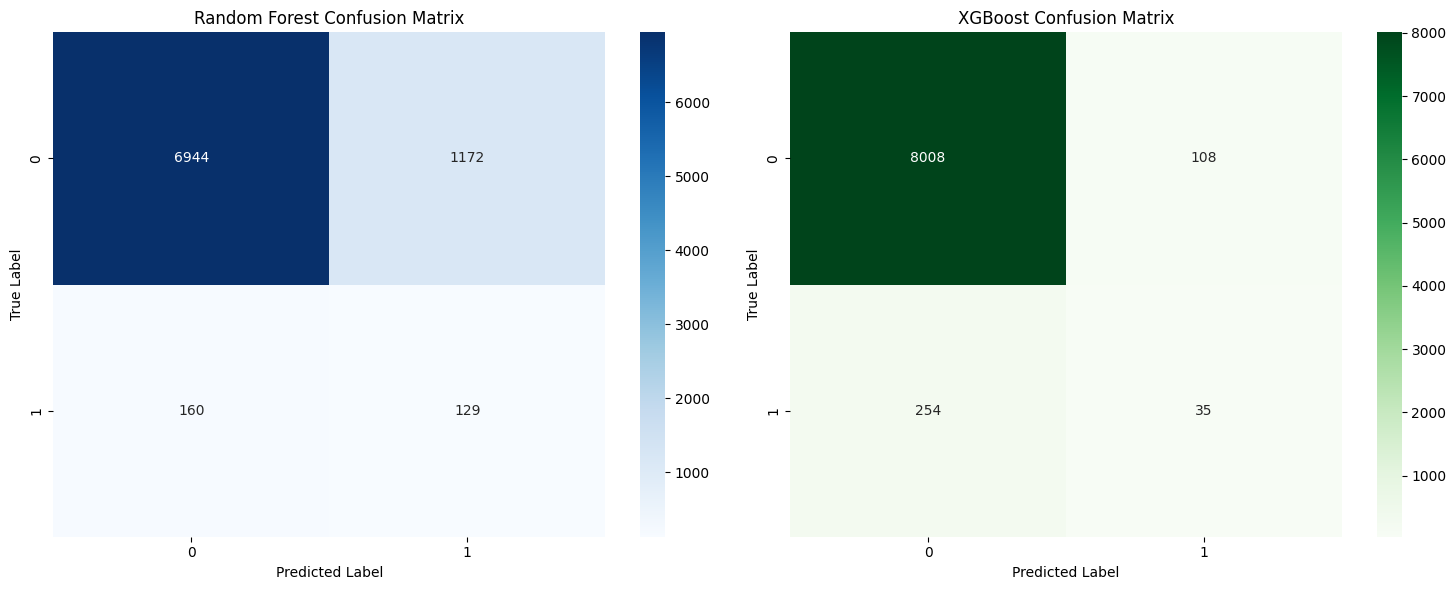

In [ ]:
##cell 23 Side by side confusion matrices
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# RF confusion matrix
cm_rf = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title('Random Forest Confusion Matrix')
ax1.set_ylabel('True Label')
ax1.set_xlabel('Predicted Label')

# XGBoost confusion matrix  
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', ax=ax2)
ax2.set_title('XGBoost Confusion Matrix')
ax2.set_ylabel('True Label')
ax2.set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

Feature importance correlation between RF and XGBoost: 0.765


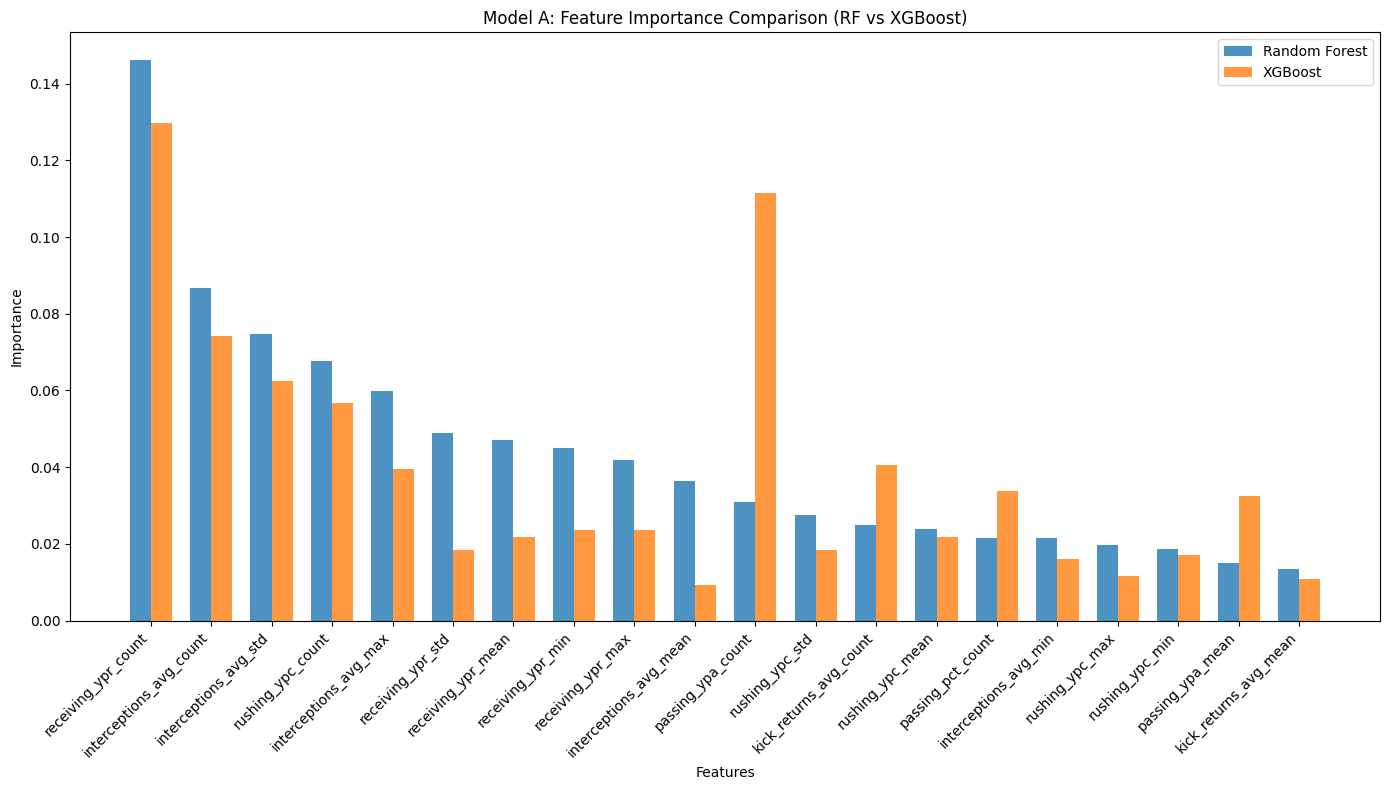


Features where XGBoost and RF disagree most:
XGBoost values higher:
                   feature  importance_rf  importance_xgb      diff
10       passing_ypa_count       0.030802        0.111496  0.080694
20  punt_returns_avg_count       0.013069        0.036958  0.023889
18        passing_ypa_mean       0.014938        0.032529  0.017591
33       kicking_pct_count       0.004234        0.021812  0.017578
12  kick_returns_avg_count       0.024959        0.040639  0.015681

Random Forest values higher:
                  feature  importance_rf  importance_xgb      diff
5       receiving_ypr_std       0.048782        0.018258 -0.030523
9  interceptions_avg_mean       0.036372        0.009331 -0.027040
6      receiving_ypr_mean       0.047179        0.021791 -0.025388
7       receiving_ypr_min       0.045037        0.023581 -0.021456
4   interceptions_avg_max       0.059888        0.039619 -0.020269


In [ ]:
# Cell 24: Compare feature importance between RF and XGBoost

importance_comparison = feature_importance.merge(
    xgb_feature_importance, 
    on='feature', 
    suffixes=('_rf', '_xgb')
)

# correlation between feature importances
importance_corr = importance_comparison[['importance_rf', 'importance_xgb']].corr().iloc[0,1]
print(f"Feature importance correlation between RF and XGBoost: {importance_corr:.3f}")

# Plot comparison 
plt.figure(figsize=(14, 8))
top_20_comparison = importance_comparison.head(20)

x = range(len(top_20_comparison))
width = 0.35

plt.bar([i - width/2 for i in x], top_20_comparison['importance_rf'], 
        width, label='Random Forest', alpha=0.8)
plt.bar([i + width/2 for i in x], top_20_comparison['importance_xgb'], 
        width, label='XGBoost', alpha=0.8)

plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Model A: Feature Importance Comparison (RF vs XGBoost)')
plt.xticks(x, top_20_comparison['feature'], rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

# biggest differences in feature importance
importance_comparison['diff'] = importance_comparison['importance_xgb'] - importance_comparison['importance_rf']
print("\nFeatures where XGBoost and RF disagree most:")
print("XGBoost values higher:")
print(importance_comparison.nlargest(5, 'diff')[['feature', 'importance_rf', 'importance_xgb', 'diff']])
print("\nRandom Forest values higher:")
print(importance_comparison.nsmallest(5, 'diff')[['feature', 'importance_rf', 'importance_xgb', 'diff']])

In [ ]:
# Cell 25: Final summary 
print(f"Dataset Overview:")
print(f"• Total players: {X_clean.shape[0]:,}")
print(f"• Features: {X_clean.shape[1]} pure efficiency metrics")
print(f"• Drafted players: {y.sum():,} ({y.mean():.1%})")
print(f"• Class imbalance ratio: {(y==0).sum()//y.sum()}:1")

print(f"\nModel Performance Comparison:")
print(f"{'Metric':<25} {'Random Forest':<15} {'XGBoost':<15} {'Winner'}")
print(f"{'-'*65}")
print(f"{'ROC AUC':<25} {rf_auc:<15.4f} {xgb_auc:<15.4f} {'XGBoost' if xgb_auc > rf_auc else 'RF'}")
print(f"{'Drafted Recall':<25} {rf_recall_drafted:<15.1%} {xgb_recall_drafted:<15.1%} {'XGBoost' if xgb_recall_drafted > rf_recall_drafted else 'RF'}")

print(f"\nTop Performance Drivers (both models agree):")
common_top_features = set(feature_importance.head(10)['feature']) & set(xgb_feature_importance.head(10)['feature'])
for i, feat in enumerate(sorted(common_top_features)[:5], 1):
    print(f"{i}. {feat}")

FINAL MODEL A SUMMARY: PURE EFFICIENCY FEATURES
Dataset Overview:
• Total players: 42,021
• Features: 34 pure efficiency metrics
• Drafted players: 1,444 (3.4%)
• Class imbalance ratio: 28:1

Model Performance Comparison:
Metric                    Random Forest   XGBoost         Winner
-----------------------------------------------------------------
ROC AUC                   0.7402          0.6992          RF
Drafted Recall            44.6%           12.1%           RF

Top Performance Drivers (both models agree):
1. interceptions_avg_count
2. interceptions_avg_max
3. interceptions_avg_std
4. receiving_ypr_count
5. rushing_ypc_count

Key Findings:
• Pure efficiency metrics achieve 74.0% AUC
• Can identify ~45% of drafted players
• Random Forest performs slightly better
• Feature importance correlation: 76.5% (models largely agree)

Ready to proceed to Model B (NFL-Realistic) and Model C (Bias-Prone)


# save results


In [ ]:

MODEL_SET_NAME = "Model_A"   # change per notebook

results_df = pd.DataFrame({
    "athlete_id": final_dataset.loc[X_test.index, "athlete_id"].values,
    "true_label": y_test.values,

    # Random Forest
    "rf_pred": y_pred,
    "rf_pred_proba": y_pred_proba[:, 1],

    # XGBoost
    "xgb_pred": y_pred_xgb,
    "xgb_pred_proba": y_pred_proba_xgb[:, 1],
})

results_df["model_set"] = MODEL_SET_NAME

os.makedirs("model_results", exist_ok=True)

output_path = f"model_results/{MODEL_SET_NAME}_results.csv"
results_df.to_csv(output_path, index=False)

print(f"saved to: {output_path}")

✅ Results saved to: model_results/Model_A_results.csv
Shape: (8405, 7)
